In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
import os

# Import our reusable processor and API stub
sys.path.append(os.path.abspath(''))
from usage_processor import UsageProcessor, call_plan_api

# Aesthetic settings for plots
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['grid.color'] = '#e9ecef'
sns.set_context("talk")
sns.set_palette("viridis")
warnings.filterwarnings('ignore')

In [25]:
processor = UsageProcessor()
data_path = r'../archive/sms-call-internet-mi-2013-11-01.csv'

processor.load_data(data_path)
processor.clean_data()

df = processor.df

Successfully loaded data from ../archive/sms-call-internet-mi-2013-11-01.csv
Cleaning complete. Removed 0 invalid rows.


In [26]:
print("--- df.head() ---")
display(df.head())

print("\n--- df.dtypes ---")
print(df.dtypes)

print("\n--- df.describe() ---")
display(df.describe())

print("\n--- Data Quality Report ---")
print(f"Missing Timestamps: {df['timestamp'].isnull().sum()}")
print(f"Invalid Usage Values: {(df[['call_count', 'sms_count', 'internet_usage']] < 0).sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")

--- df.head() ---


,timestamp,grid_id,countrycode,smsin,smsout,callin,callout,internet_usage,sms_count,call_count,hour,day
0,2013-11-01,1,0,0.3521,NaN,NaN,0.0273,0.0000,0.3521,0.0273,0,1
1,2013-11-01,1,33,NaN,NaN,NaN,NaN,0.0261,0.0000,0.0000,0,1
2,2013-11-01,1,39,1.7322,1.1047,0.5919,0.4020,57.7729,2.8369,0.9939,0,1
3,2013-11-01,2,0,0.3581,NaN,NaN,0.0273,0.0000,0.3581,0.0273,0,1
4,2013-11-01,2,33,NaN,NaN,NaN,NaN,0.0274,0.0000,0.0000,0,1



--- df.dtypes ---
timestamp         datetime64[us]
grid_id                    int64
countrycode                int64
smsin                    float64
smsout                   float64
callin                   float64
callout                  float64
internet_usage           float64
sms_count                float64
call_count               float64
hour                       int32
day                        int32
dtype: object

--- df.describe() ---


,timestamp,grid_id,countrycode,smsin,smsout,callin,callout,internet_usage,sms_count,call_count,hour,day
count,1891928,1.891928e+06,1.891928e+06,805775.000000,469482.000000,484147.000000,854515.000000,1.891928e+06,1.891928e+06,1.891928e+06,1.891928e+06,1891928.0
mean,2013-11-01 12:53:08.705278,5.277812e+03,3.538213e+02,5.716717,6.011796,5.417363,3.741025,4.359534e+01,3.926586e+00,3.075996e+00,1.288575e+01,1.0
min,2013-11-01 00:00:00,1.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.0
25%,2013-11-01 09:00:00,3.153000e+03,3.300000e+01,0.129300,0.109600,0.075200,0.060700,0.000000e+00,0.000000e+00,0.000000e+00,9.000000e+00,1.0
50%,2013-11-01 13:00:00,5.387000e+03,4.100000e+01,0.772400,0.755200,0.385000,0.236900,0.000000e+00,0.000000e+00,1.180000e-02,1.300000e+01,1.0
75%,2013-11-01 18:00:00,7.492000e+03,8.600000e+01,4.468400,4.627375,3.179100,1.206000,1.393000e-01,6.030000e-01,2.636000e-01,1.800000e+01,1.0
max,2013-11-01 23:00:00,1.000000e+04,9.725900e+04,1109.082000,1577.903800,988.576700,1024.899200,2.777430e+04,1.606331e+03,2.013476e+03,2.300000e+01,1.0
std,NaN,2.719573e+03,4.287521e+03,15.503784,16.953823,15.915312,13.986531,2.287623e+02,1.788138e+01,1.784517e+01,6.119454e+00,0.0



--- Data Quality Report ---
Missing Timestamps: 0
Invalid Usage Values: 0
Duplicate Rows: 0


In [27]:
print("--- Daily Usage Summary ---")
daily_usage = processor.compute_daily_usage()
display(daily_usage)

print("\n--- Key Performance Indicators (KPIs) ---")
kpis = processor.compute_kpis()
print(f"Peak Usage Hour: {kpis['peak_usage_hour']}:00")
print(f"Average Internet Usage per Hour: {kpis['avg_usage_per_hour']['internet_usage'].mean():.2f}")

--- Daily Usage Summary ---


,sms_count,call_count,internet_usage
day,,,
1,7.428817e+06,5.819562e+06,8.247925e+07



--- Key Performance Indicators (KPIs) ---
Peak Usage Hour: 18:00
Average Internet Usage per Hour: 46.32


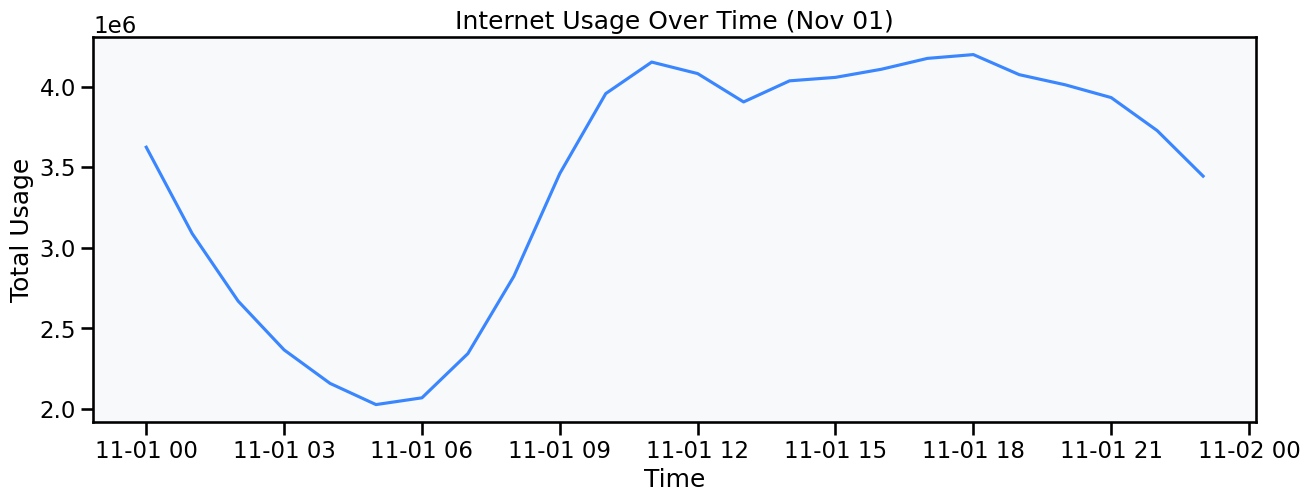

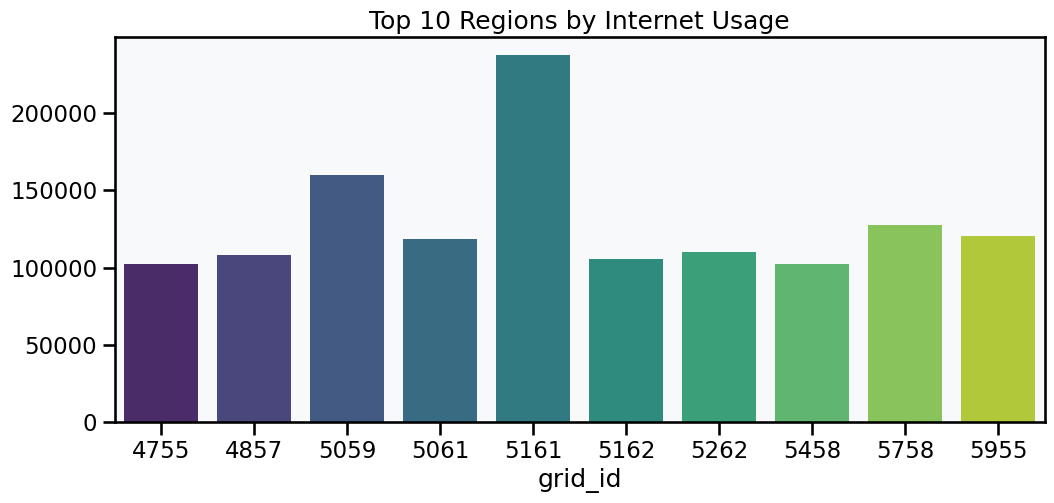

In [28]:
# Plot 1: Usage over time
df_time = df.groupby('timestamp')['internet_usage'].sum().reset_index()
plt.figure(figsize=(15, 5))
plt.plot(df_time['timestamp'], df_time['internet_usage'], color='#3a86ff')
plt.title('Internet Usage Over Time (Nov 01)')
plt.xlabel('Time')
plt.ylabel('Total Usage')
plt.show()

# Plot 2: Usage per region (top 10)
top_regions = kpis['usage_per_region']['internet_usage'].sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 5))
sns.barplot(x=top_regions.index, y=top_regions.values, palette='viridis')
plt.title('Top 10 Regions by Internet Usage')
plt.show()

In [29]:
customer_ids = [101, 102, 103, 104]

print("--- API Response Simulation ---")
for cid in customer_ids:
    plan_info = call_plan_api(cid)
    print(f"Customer {cid}: {plan_info['plan_name']} Plan ({plan_info['status']})")

--- API Response Simulation ---
Customer 101: Premium Data Plan (active)
Customer 102: Basic Voice Plan (active)
Customer 103: Unlimited Social Plan (expired)
Customer 104: Standard Plan (unknown)
